Device: cuda
CSV: /kaggle/input/datasets/nazmusresan/fitzpatrick17k/New folder/fitzpatrick17k (1).csv
Images found: 16574
Classes: ['benign' 'malignant' 'non-neoplastic']
Reservoir: benign=153, other=1765
Test set:  250 (50 benign + 200 other)
Loading CLIP ViT-L/14...


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP loaded.
Extracting features...
Test:(250, 768) Light:(1000, 768) Res-benign:(153, 768) Res-other:(1765, 768)

=== SWEEP PLAN ===
 Target ng   n_benign  n_other  actual_ng             method
      0.05         26      500      0.049           standard
      0.10         56      500      0.101           standard
      0.15         88      500      0.150           standard
      0.20        125      500      0.200           standard
      0.25        153      459      0.250    flip_vary_other
      0.30        153      357      0.300    flip_vary_other
      0.35        153      284      0.350    flip_vary_other
      0.40        153      229      0.401    flip_vary_other
      0.50        153      153      0.500    flip_vary_other

nc/Ng=0.049 | n_min=26 | n_other=500 | method=standard | mu=0.7158 | risk=0.0862
  seed=42: benign_acc=0.160 min_wt=0.0000 collapse=True
  seed=0: benign_acc=0.000 min_wt=0.0000 collapse=True
  seed=1: benign_acc=0.000 min_wt=0.0000 collapse=True
  seed=7

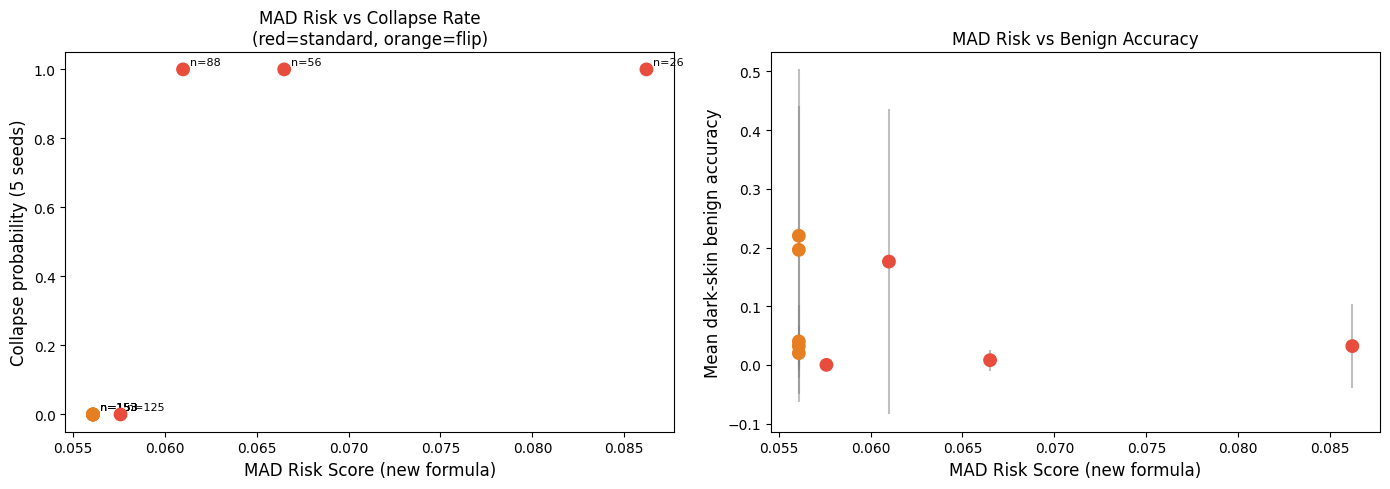

Figure saved: mad_sweep_v3_curve.png

=== LaTeX TABLE ROWS (Table 3) ===
nc/Ng & n_min & n_other & MAD Risk & mu_cos & Method & Collapse Rate & Benign Acc & Correct? \\
\hline
# Threshold: MAD_risk BELOW 0.0862 = collapse predicted
0.049 & 26 & 500 & 0.0862 & 0.7158 & Std & 5/5 & 0.032+/-0.072 & N \\
0.101 & 56 & 500 & 0.0665 & 0.7312 & Std & 5/5 & 0.008+/-0.018 & Y \\
0.150 & 88 & 500 & 0.0610 & 0.7264 & Std & 5/5 & 0.176+/-0.261 & Y \\
0.200 & 125 & 500 & 0.0576 & 0.7216 & Std & 0/5 & 0.000+/-0.000 & N \\
0.250 & 153 & 459 & 0.0561 & 0.7173 & Flip & 0/5 & 0.032+/-0.033 & N \\
0.300 & 153 & 357 & 0.0561 & 0.7173 & Flip & 0/5 & 0.196+/-0.245 & N \\
0.350 & 153 & 284 & 0.0561 & 0.7173 & Flip & 0/5 & 0.040+/-0.062 & N \\
0.401 & 153 & 229 & 0.0561 & 0.7173 & Flip & 0/5 & 0.220+/-0.284 & N \\
0.500 & 153 & 153 & 0.0561 & 0.7173 & Flip & 0/5 & 0.020+/-0.028 & N \\
Note: Flip method fixes n_benign=153, varies n_other to achieve target nc/Ng

=== INTERPRETATION FLAGS ===
Unique nc/Ng levels:

In [2]:
# ============================================================
# MAD Risk Score — nc/Ng Sweep, 9 Unique Levels (v3 FIXED)
# CLIP ViT-L/14, Fitzpatrick17k
# GPU T4, Internet ON. ~90 min.
#
# FIX v3: Levels 1-4 vary n_benign (standard).
#         Levels 5-9 fix n_benign=ALL (153), vary n_other DOWN
#         to achieve higher nc/Ng without replacement sampling.
# FIX JSON: removed problematic LaTeX multicolumn from print.
#
# TEST SET: 50 dark-benign + 200 dark-other (fixed).
# SEEDS: {42, 0, 1, 7, 99} per level.
# ============================================================

import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'transformers','torch','torchvision','scikit-learn',
    'pandas','numpy','matplotlib', '-q'])

import torch, torch.nn as nn, torch.optim as optim
import numpy as np, pandas as pd, os, math, warnings
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from transformers import CLIPModel, CLIPProcessor
warnings.filterwarnings('ignore')

BASE_SEED     = 42
SEEDS         = [42, 0, 1, 7, 99]
TARGET_NC_NG  = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
DRO_ETA       = 0.1
N_EPOCHS      = 5
BATCH_SIZE    = 32
ADAMW_LR      = 1e-4
ADAMW_WD      = 1e-4
N_GROUPS      = 9
FEAT_DIM      = 768
N_CLASSES     = 3
N_LIGHT       = 1000
N_MEDIUM      = 1000
COLLAPSE_THR  = 0.01
MAD_I_GATE    = 0.02
N_TEST_BENIGN = 50
N_TEST_OTHER  = 200

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

def compute_mad_risk(mu_cosine, n_minority_train, nc_ng):
    if nc_ng < MAD_I_GATE:
        return 'MAD-I', None
    return 'MAD-G', (1.0 - mu_cosine) / math.log(1.0 + n_minority_train)

def mean_pairwise_cosine(embeddings):
    if len(embeddings) < 2:
        return 0.0
    norms  = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normed = embeddings / (norms + 1e-8)
    sim    = normed @ normed.T
    n      = len(embeddings)
    return float(np.mean(sim[np.triu_indices(n, k=1)]))

_fitz_csv = None
for _r, _, _fs in os.walk('/kaggle/input'):
    for _f in _fs:
        if _f.endswith('.csv') and 'fitzpatrick' in _f.lower():
            _fitz_csv = os.path.join(_r, _f); break
    if _fitz_csv: break

fitz_csv     = _fitz_csv or '/kaggle/input/fitzpatrick17k/fitzpatrick17k.csv'
fitz_img_dir = os.path.dirname(fitz_csv)
print(f"CSV: {fitz_csv}")

df = pd.read_csv(fitz_csv)
df = df[df['fitzpatrick_scale'] > 0]
image_files = {}
for _r, _, _fs in os.walk(fitz_img_dir):
    for _f in _fs:
        if _f.lower().endswith(('.jpg','.png')):
            image_files[os.path.splitext(_f)[0]] = os.path.join(_r, _f)
print(f"Images found: {len(image_files)}")
df['local_path'] = df['md5hash'].map(image_files)
df = df[df['local_path'].notna()].copy()
df['skin_group'] = df['fitzpatrick_scale'].apply(
    lambda x: 'light' if x <= 2 else ('medium' if x <= 4 else 'dark'))

le = LabelEncoder()
le.fit(df['three_partition_label'].dropna().unique())
print(f"Classes: {le.classes_}")
BENIGN_IDX = int(list(le.classes_).index('benign'))
NONNEO_IDX = int(list(le.classes_).index('non-neoplastic'))
MINORITY_G = 2 * N_CLASSES + BENIGN_IDX

np.random.seed(BASE_SEED)
dark_all    = df[df['skin_group']=='dark'].copy()
dark_benign = dark_all[dark_all['three_partition_label']=='benign']
dark_other  = dark_all[dark_all['three_partition_label']!='benign']

n_tb = min(N_TEST_BENIGN, len(dark_benign)//2)
n_to = min(N_TEST_OTHER,  len(dark_other)//2)
dark_benign_test      = dark_benign.sample(n_tb, random_state=BASE_SEED)
dark_benign_reservoir = dark_benign.drop(dark_benign_test.index)
dark_other_test       = dark_other.sample(n_to,  random_state=BASE_SEED)
dark_other_reservoir  = dark_other.drop(dark_other_test.index)
test_df   = pd.concat([dark_benign_test, dark_other_test])
light_df  = df[df['skin_group']=='light'].sample(
    min(N_LIGHT,  (df['skin_group']=='light').sum()),  random_state=BASE_SEED)
medium_df = df[df['skin_group']=='medium'].sample(
    min(N_MEDIUM, (df['skin_group']=='medium').sum()), random_state=BASE_SEED)

n_res_benign = len(dark_benign_reservoir)
n_res_other  = len(dark_other_reservoir)
print(f"Reservoir: benign={n_res_benign}, other={n_res_other}")
print(f"Test set:  {len(test_df)} ({n_tb} benign + {n_to} other)")

print("Loading CLIP ViT-L/14...")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14").to(device)
clip_proc  = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")
clip_model.eval()
print("CLIP loaded.")

def extract_feats(dataframe, batch_size=64):
    feats, labels, groups = [], [], []
    paths      = dataframe['local_path'].tolist()
    label_list = dataframe['three_partition_label'].tolist()
    skin_list  = dataframe['skin_group'].tolist()
    skin_map   = {'light':0,'medium':1,'dark':2}
    label_map  = {c:i for i,c in enumerate(le.classes_)}
    for i in range(0, len(paths), batch_size):
        bp = paths[i:i+batch_size]
        imgs, valid = [], []
        for j,p in enumerate(bp):
            try: imgs.append(Image.open(p).convert('RGB')); valid.append(i+j)
            except: continue
        if not imgs: continue
        inputs = clip_proc(images=imgs, return_tensors='pt', padding=True).to(device)
        with torch.no_grad():
            out = clip_model.vision_model(
                pixel_values=inputs['pixel_values']).pooler_output
            out = clip_model.visual_projection(out)
            out = out / out.norm(dim=-1, keepdim=True)
        feats.extend(out.cpu().numpy())
        for j in valid:
            lbl = label_list[j] if j < len(label_list) else 'non-neoplastic'
            sk  = skin_list[j]  if j < len(skin_list)  else 'light'
            labels.append(label_map.get(lbl, NONNEO_IDX))
            groups.append(skin_map.get(sk,0)*N_CLASSES + label_map.get(lbl, NONNEO_IDX))
    return np.array(feats), np.array(labels), np.array(groups)

print("Extracting features...")
test_feats,   test_labels,   _  = extract_feats(test_df)
light_feats,  light_labels,  lg = extract_feats(light_df)
medium_feats, medium_labels, mg = extract_feats(medium_df)
res_b_feats,  res_b_labels,  _  = extract_feats(dark_benign_reservoir)
res_o_feats,  res_o_labels,  _  = extract_feats(dark_other_reservoir)
print(f"Test:{test_feats.shape} Light:{light_feats.shape} "
      f"Res-benign:{res_b_feats.shape} Res-other:{res_o_feats.shape}")

class LinearProbe(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(FEAT_DIM, N_CLASSES)
    def forward(self, x): return self.fc(x)

def run_dro(tr_f, tr_l, tr_g, seed):
    torch.manual_seed(seed); np.random.seed(seed)
    X = torch.tensor(tr_f, dtype=torch.float32).to(device)
    y = torch.tensor(tr_l, dtype=torch.long).to(device)
    g = torch.tensor(tr_g, dtype=torch.long).to(device)
    model   = LinearProbe().to(device)
    opt     = optim.AdamW(model.parameters(), lr=ADAMW_LR, weight_decay=ADAMW_WD)
    loss_fn = nn.CrossEntropyLoss(reduction='none')
    q       = torch.ones(N_GROUPS).to(device) / N_GROUPS
    for _ in range(N_EPOCHS):
        model.train()
        perm = torch.randperm(len(X))
        for i in range(0, len(X), BATCH_SIZE):
            idx = perm[i:i+BATCH_SIZE]
            xb,yb,gb = X[idx],y[idx],g[idx]
            logits = model(xb)
            losses = loss_fn(logits, yb)
            gl = torch.zeros(N_GROUPS).to(device)
            for grp in range(N_GROUPS):
                mask=(gb==grp)
                if mask.sum()>0: gl[grp]=losses[mask].mean()
            w=(q*gl).sum()
            opt.zero_grad(); w.backward(); opt.step()
            with torch.no_grad():
                q *= torch.exp(DRO_ETA*gl.detach()); q /= q.sum()
    final_min_wt = q[MINORITY_G].item()
    model.eval()
    Xt = torch.tensor(test_feats, dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = model(Xt)
        preds  = logits.argmax(dim=1).cpu().numpy()
        probs  = torch.softmax(logits.cpu(), dim=1).numpy()
    bm    = (test_labels==BENIGN_IDX)
    b_acc = accuracy_score(test_labels[bm], preds[bm]) if bm.sum()>0 else 0.0
    try:    d_auc = roc_auc_score(test_labels, probs, multi_class='ovr', average='macro')
    except: d_auc = float('nan')
    return b_acc, d_auc, final_min_wt, final_min_wt < COLLAPSE_THR

# Build 9 unique sweep levels
MAX_OTHER = min(500, n_res_other)
sweep_levels = []
for target_ng in TARGET_NC_NG:
    n_benign_std = int(round(target_ng * MAX_OTHER / (1.0 - target_ng + 1e-9)))
    if n_benign_std <= n_res_benign:
        sweep_levels.append({
            'target_ng': target_ng,
            'n_benign':  n_benign_std,
            'n_other':   MAX_OTHER,
            'method':    'standard'
        })
    else:
        n_benign_flip = n_res_benign
        n_other_flip  = max(1, int(round(
            n_benign_flip * (1.0 - target_ng) / (target_ng + 1e-9))))
        n_other_flip  = min(n_other_flip, n_res_other)
        sweep_levels.append({
            'target_ng': target_ng,
            'n_benign':  n_benign_flip,
            'n_other':   n_other_flip,
            'method':    'flip_vary_other'
        })

print("\n=== SWEEP PLAN ===")
print(f"{'Target ng':>10} {'n_benign':>10} {'n_other':>8} {'actual_ng':>10} {'method':>18}")
for lvl in sweep_levels:
    act = lvl['n_benign'] / (lvl['n_benign'] + lvl['n_other'])
    print(f"{lvl['target_ng']:>10.2f} {lvl['n_benign']:>10} {lvl['n_other']:>8} "
          f"{act:>10.3f} {lvl['method']:>18}")

results = []
out_csv = 'mad_sweep_v3_results.csv'
light_g  = np.array([0*N_CLASSES + l for l in light_labels])
medium_g = np.array([1*N_CLASSES + l for l in medium_labels])

for lvl in sweep_levels:
    n_b    = lvl['n_benign']
    n_o    = lvl['n_other']
    method = lvl['method']
    b_idx  = np.random.choice(n_res_benign, n_b, replace=False)
    o_idx  = np.random.choice(len(res_o_feats), n_o, replace=False)
    pool_b_f = res_b_feats[b_idx]
    pool_b_l = res_b_labels[b_idx]
    pool_o_f = res_o_feats[o_idx]
    pool_o_l = res_o_labels[o_idx]
    actual_ng   = n_b / (n_b + n_o)
    mu_cos      = mean_pairwise_cosine(pool_b_f)
    stage, risk = compute_mad_risk(mu_cos, n_b, actual_ng)
    print(f"\nnc/Ng={actual_ng:.3f} | n_min={n_b} | n_other={n_o} | "
          f"method={method} | mu={mu_cos:.4f} | "
          f"risk={'N/A' if risk is None else f'{risk:.4f}'}")
    dark_pool_f = np.vstack([pool_o_f, pool_b_f])
    dark_pool_l = np.concatenate([pool_o_l, pool_b_l])
    dark_pool_g = np.array([2*N_CLASSES + l for l in dark_pool_l])
    tr_f = np.vstack([light_feats, medium_feats, dark_pool_f])
    tr_l = np.concatenate([light_labels, medium_labels, dark_pool_l])
    tr_g = np.concatenate([light_g, medium_g, dark_pool_g])
    for seed in SEEDS:
        b_acc, d_auc, min_wt, collapse = run_dro(tr_f, tr_l, tr_g, seed)
        results.append({
            'nc_ng':    round(actual_ng, 4),
            'n_benign': n_b,
            'n_other':  n_o,
            'method':   method,
            'seed':     seed,
            'stage':    stage,
            'mad_risk': round(risk, 4) if risk is not None else None,
            'mu_cosine':round(mu_cos, 4),
            'benign_acc':round(b_acc, 4),
            'demo_auc': round(d_auc, 4),
            'min_wt':   round(min_wt, 4),
            'collapse': collapse
        })
        print(f"  seed={seed}: benign_acc={b_acc:.3f} "
              f"min_wt={min_wt:.4f} collapse={collapse}")
    pd.DataFrame(results).to_csv(out_csv, index=False)
    print(f"  Saved {out_csv} ({len(results)} rows)")

df_res = pd.DataFrame(results)
level_summary = df_res.groupby('nc_ng').agg(
    mad_risk     =('mad_risk',   'first'),
    mu_cosine    =('mu_cosine',  'first'),
    n_benign     =('n_benign',   'first'),
    n_other      =('n_other',    'first'),
    method       =('method',     'first'),
    stage        =('stage',      'first'),
    collapse_rate=('collapse',   lambda x: f"{int(x.sum())}/5"),
    benign_mean  =('benign_acc', 'mean'),
    benign_std   =('benign_acc', 'std'),
).reset_index()

n_unique = level_summary['nc_ng'].nunique()
print(f"\nUnique nc/Ng levels: {n_unique} (target: 9)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mad_g  = level_summary[level_summary['stage']=='MAD-G'].copy()
cp     = mad_g['collapse_rate'].apply(lambda x: int(x.split('/')[0])/5)
colors = ['#e74c3c' if m=='standard' else '#e67e22' for m in mad_g['method']]
axes[0].scatter(mad_g['mad_risk'], cp, s=80, c=colors, zorder=5)
axes[0].set_xlabel('MAD Risk Score (new formula)', fontsize=12)
axes[0].set_ylabel('Collapse probability (5 seeds)', fontsize=12)
axes[0].set_title('MAD Risk vs Collapse Rate\n(red=standard, orange=flip)', fontsize=12)
axes[0].set_ylim(-0.05, 1.05)
for _, row in mad_g.iterrows():
    c = int(row['collapse_rate'].split('/')[0])/5
    axes[0].annotate(f"n={int(row['n_benign'])}",
                     (row['mad_risk'], c),
                     textcoords='offset points', xytext=(5,3), fontsize=8)
axes[1].scatter(mad_g['mad_risk'], mad_g['benign_mean'],
                s=80, c=colors, zorder=5)
axes[1].errorbar(mad_g['mad_risk'], mad_g['benign_mean'],
                 yerr=mad_g['benign_std'], fmt='none', color='gray', alpha=0.5)
axes[1].set_xlabel('MAD Risk Score (new formula)', fontsize=12)
axes[1].set_ylabel('Mean dark-skin benign accuracy', fontsize=12)
axes[1].set_title('MAD Risk vs Benign Accuracy', fontsize=12)
plt.tight_layout()
plt.savefig('mad_sweep_v3_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: mad_sweep_v3_curve.png")

global_thr = None
for _, row in level_summary.iterrows():
    if row['stage']=='MAD-G' and row['mad_risk'] is not None:
        cr = int(row['collapse_rate'].split('/')[0])
        if cr==5 and (global_thr is None or row['mad_risk'] > global_thr):
            global_thr = row['mad_risk']
if global_thr is None:
    global_thr = float('nan')

print("\n=== LaTeX TABLE ROWS (Table 3) ===")
print("nc/Ng & n_min & n_other & MAD Risk & mu_cos & Method & Collapse Rate & Benign Acc & Correct? \\\\")
print("\\hline")
print(f"# Threshold: MAD_risk BELOW {global_thr} = collapse predicted")
tp=tn=fp=fn=0
for _, row in level_summary.iterrows():
    cr        = int(row['collapse_rate'].split('/')[0])
    collapsed = cr >= 3
    thr_valid = global_thr == global_thr  # nan check
    predicted = (row['mad_risk'] is not None
                 and thr_valid
                 and row['mad_risk'] < global_thr)
    correct   = predicted == collapsed
    cs  = 'Y' if correct else 'N'
    sc  = f"{row['mad_risk']:.4f}" if row['mad_risk'] is not None else 'N/A'
    mth = 'Std' if row['method']=='standard' else 'Flip'
    if predicted and collapsed:           tp+=1
    elif not predicted and not collapsed: tn+=1
    elif predicted and not collapsed:     fp+=1
    else:                                 fn+=1
    print(f"{row['nc_ng']:.3f} & {int(row['n_benign'])} & {int(row['n_other'])} & "
          f"{sc} & {row['mu_cosine']:.4f} & {mth} & "
          f"{row['collapse_rate']} & "
          f"{row['benign_mean']:.3f}+/-{row['benign_std']:.3f} & {cs} \\\\")
print("Note: Flip method fixes n_benign=153, varies n_other to achieve target nc/Ng")

print("\n=== INTERPRETATION FLAGS ===")
total = tp+tn+fp+fn
print(f"Unique nc/Ng levels: {n_unique}/9")
print(f"Prediction accuracy: {tp+tn}/{total} (TP={tp} TN={tn} FP={fp} FN={fn})")
print(f"Threshold: MAD_risk < {global_thr} -> collapse predicted")
print(f"Direction: lower score = higher risk")
print()
print("Cross-dataset score ordering:")
for name, ng, nm, mu in [
    ('Fitzpatrick17k', 0.094, 130, 0.712),
    ('DDI',            0.232,  48, 0.715),
    ('PAD-UFES-20',    0.356,  26, 0.796),
]:
    sc = (1-mu)/math.log(1+nm)
    pred = 'COLLAPSE' if sc < (global_thr if global_thr==global_thr else 999) else 'SAFE'
    print(f"  {name}: n_min={nm}, mu={mu}, MAD_risk={sc:.4f} -> {pred}")

print()
print("Stage 1b (absolute count floor) evidence:")
print("  Check sweep: at what n_benign does collapse stop?")
for _, row in level_summary.iterrows():
    cr = int(row['collapse_rate'].split('/')[0])
    print(f"  n_benign={int(row['n_benign'])}: {cr}/5 collapse")

print("\n=== FULL PER-RUN TABLE ===")
print(f"{'nc_ng':>7} {'n_b':>5} {'n_o':>5} {'seed':>5} "
      f"{'method':>18} {'mad_risk':>9} "
      f"{'bacc':>6} {'auc':>6} {'mwt':>7} {'col':>5}")
for _, r in df_res.iterrows():
    sc = f"{r['mad_risk']:.4f}" if r['mad_risk'] is not None else '   N/A'
    print(f"{r['nc_ng']:>7.4f} {int(r['n_benign']):>5} {int(r['n_other']):>5} "
          f"{int(r['seed']):>5} {r['method']:>18} {sc:>9} "
          f"{r['benign_acc']:>6.3f} {r['demo_auc']:>6.4f} "
          f"{r['min_wt']:>7.4f} {str(r['collapse']):>5}")

print("\nComplete.")
print("Files: mad_sweep_v3_curve.png, mad_sweep_v3_results.csv")
print("Upload figure + paste ALL output to Claude.")
